# 02 · The SQL face of both databases
*Everything exports to standard SQL — the most portable analysis surface there is.*

`oneuniverse` can materialise its two on-disk formats into **SQLite** (stdlib, single portable file) or generate **zero-copy DuckDB views** over the existing parquet. The design mirrors the package's own storage philosophy: *materialise* ≡ re-encode, *attach* ≡ wrap-in-place. Real eBOSS data throughout.

In [1]:
%matplotlib inline
import os, sys, json, time, sqlite3, tempfile, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, healpy as hp
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrow, Rectangle, FancyBboxPatch
plt.rcParams.update({'figure.dpi':115,'font.size':10.5,'axes.titlesize':11.5,
    'axes.titleweight':'bold','axes.spines.top':False,'axes.spines.right':False,
    'figure.facecolor':'white'})
C0,C1,C2,C3,C4 = '#3a6ea5','#d1495b','#3c8d53','#edae49','#7d5ba6'
ROOT = Path.cwd().parent; sys.path.insert(0, str(ROOT/'test'))
TMP = Path(tempfile.mkdtemp())
DATA_ROOT='/home/ravoux/Documents/Science/Cosmography/oneuniverse_data'
EBOSS=Path(DATA_ROOT)/'spectroscopic/eboss/qso/DR16Q_Superset_v3.fits'
DESI =Path(DATA_ROOT)/'spectroscopic/desi/dr1/qso/QSO_full.dat.fits'
HAVE_REAL = EBOSS.exists() and DESI.exists()
from oneuniverse.simulation.cosmology import CosmologySpec
COSMO = CosmologySpec(omega_m=0.31, omega_b=0.048, h=0.67, n_s=0.96, sigma8=0.81, t_cmb=2.7255)
def moll(ax, ra, dec, **kw):
    lon = np.radians(((np.asarray(ra)+180)%360)-180)
    ax.scatter(lon, np.radians(dec), **kw)
print('real eBOSS+DESI available:', HAVE_REAL)

/home/ravoux/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


real eBOSS+DESI available: True


## The schema at a glance

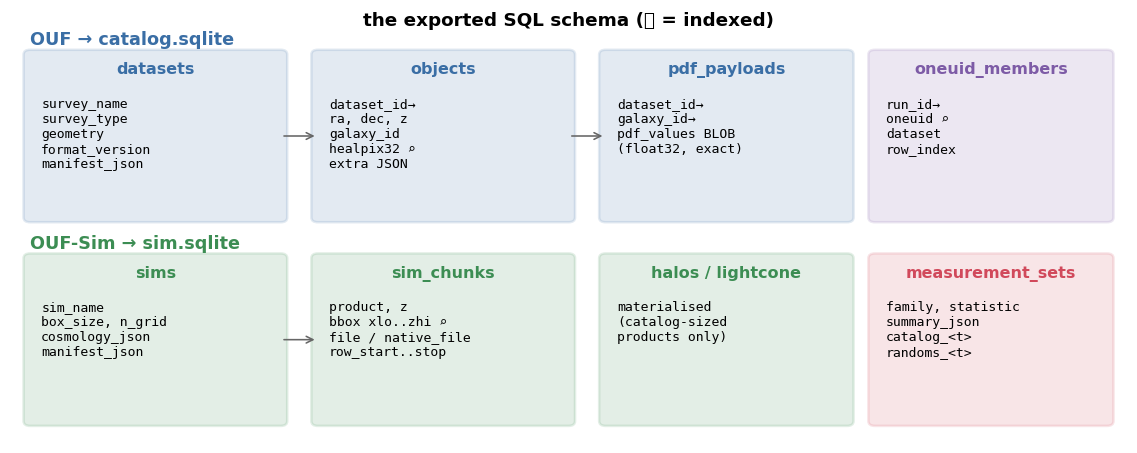

In [2]:
fig,ax=plt.subplots(figsize=(12.5,4.6)); ax.axis('off'); ax.set_xlim(0,12); ax.set_ylim(0,6)
def box(x,y,w,h,title,rows,color):
    ax.add_patch(FancyBboxPatch((x,y),w,h,boxstyle='round,pad=0.07',fc=color,alpha=.14,ec=color,lw=1.6))
    ax.text(x+w/2,y+h-0.28,title,ha='center',fontsize=10,fontweight='bold',color=color)
    ax.text(x+0.12,y+h-0.62,rows,fontsize=8.2,va='top',family='monospace')
box(0.2,3.3,2.7,2.4,'datasets','survey_name\nsurvey_type\ngeometry\nformat_version\nmanifest_json',C0)
box(3.3,3.3,2.7,2.4,'objects','dataset_id→\nra, dec, z\ngalaxy_id\nhealpix32 ⌕\nextra JSON',C0)
box(6.4,3.3,2.6,2.4,'pdf_payloads','dataset_id→\ngalaxy_id→\npdf_values BLOB\n(float32, exact)',C0)
box(9.3,3.3,2.5,2.4,'oneuid_members','run_id→\noneuid ⌕\ndataset\nrow_index',C4)
box(0.2,0.3,2.7,2.4,'sims','sim_name\nbox_size, n_grid\ncosmology_json\nmanifest_json',C2)
box(3.3,0.3,2.7,2.4,'sim_chunks','product, z\nbbox xlo..zhi ⌕\nfile / native_file\nrow_start..stop',C2)
box(6.4,0.3,2.6,2.4,'halos / lightcone','materialised\n(catalog-sized\nproducts only)',C2)
box(9.3,0.3,2.5,2.4,'measurement_sets','family, statistic\nsummary_json\ncatalog_<t>\nrandoms_<t>',C1)
ax.annotate('',(3.3,4.5),(2.9,4.5),arrowprops=dict(arrowstyle='->',color='.4'))
ax.annotate('',(6.4,4.5),(6.0,4.5),arrowprops=dict(arrowstyle='->',color='.4'))
ax.annotate('',(3.3,1.5),(2.9,1.5),arrowprops=dict(arrowstyle='->',color='.4'))
ax.text(0.2,5.85,'OUF → catalog.sqlite',fontsize=11,fontweight='bold',color=C0)
ax.text(0.2,2.85,'OUF-Sim → sim.sqlite',fontsize=11,fontweight='bold',color=C2)
ax.set_title('the exported SQL schema (⌕ = indexed)'); plt.show()

## Real eBOSS → `catalog.sqlite`, queried in pure SQL
Export, then answer survey questions with SQL alone: a z-histogram by `GROUP BY`, and a sky cone as a HEALPix `WHERE IN` — the package's partition pruning, expressed relationally.

exported 50,000 real rows -> catalog.sqlite (6.1 MB) in 0.6s


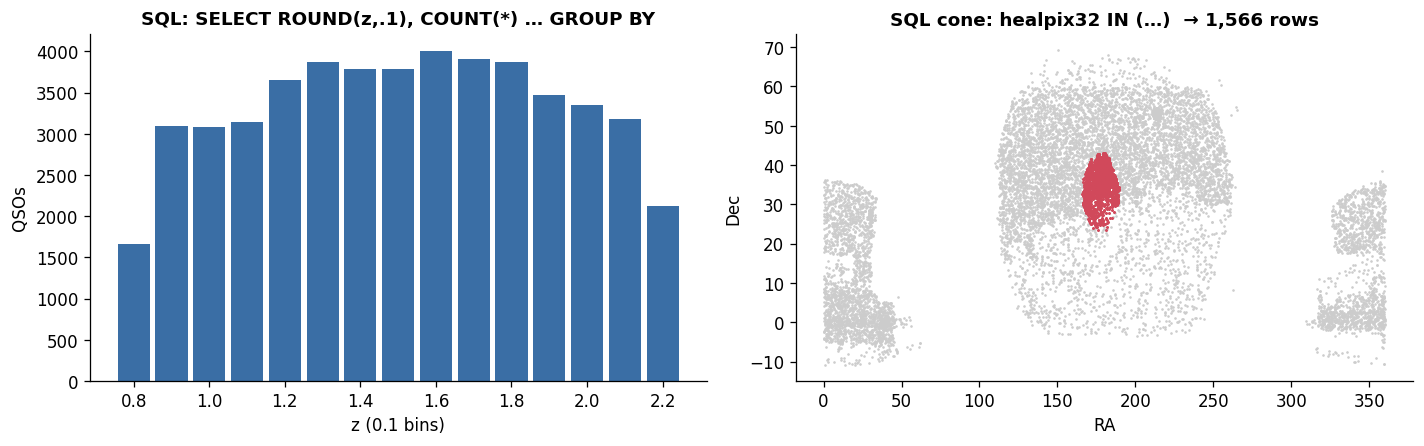

In [3]:
def load_qso(name, zlo=0.8, zhi=2.2, cap=60000, seed=0):
    '''Real survey catalog via the registered P1 loader (synthetic fallback).'''
    if not HAVE_REAL:
        from fixtures.measure_ouf import synthetic_point_view
        return synthetic_point_view(TMP, n=cap, seed=seed, name=name).read(), False
    os.environ['ONEUNIVERSE_DATA_ROOT']=DATA_ROOT
    from oneuniverse.data import load_catalog
    df = load_catalog(name, validate=False)
    df = df[(df['z']>=zlo)&(df['z']<=zhi)].dropna(subset=['ra','dec','z'])
    if len(df)>cap: df=df.sample(cap, random_state=seed)
    return df.reset_index(drop=True), True
def to_ouf_view(df, tmp, name, extra_cols=()):
    '''Write a DataFrame as an OUF 2.6 POINT dataset; return its DatasetView.'''
    from oneuniverse.data.converter import write_ouf_dataset
    from oneuniverse.data.dataset_view import DatasetView
    from oneuniverse.data.format_spec import DataGeometry
    from oneuniverse.data.manifest import LoaderSpec
    n=len(df); ra=df['ra'].to_numpy(float); dec=df['dec'].to_numpy(float)
    out={'ra':ra,'dec':dec,'z':df['z'].to_numpy(float),'z_type':np.full(n,'spec'),
         'z_err':np.full(n,1e-4),'galaxy_id':np.arange(n,dtype=np.int64),
         'survey_id':np.zeros(n,dtype=np.int64),'weight_comp':np.ones(n),
         '_original_row_index':np.arange(n,dtype='i8'),
         '_healpix32':hp.ang2pix(32,ra,dec,nest=True,lonlat=True).astype('i4')}
    for c in extra_cols:
        out[c]=df[c].to_numpy()
    od=tmp/name/'oneuniverse'
    write_ouf_dataset(df=pd.DataFrame(out),out_dir=od,survey_name=name,
        survey_type='spectroscopic',geometry=DataGeometry.POINT,
        loader=LoaderSpec(name=name,version='0'))
    return DatasetView.from_path(od.parent)
from oneuniverse.data.sql import export_sql, attach_sql_ddl
eb,real = load_qso('eboss_qso', cap=50000, seed=1)
view = to_ouf_view(eb, TMP, 'eboss')
t0=time.perf_counter(); db = export_sql([view], TMP/'catalog.sqlite'); t_exp=time.perf_counter()-t0
con = sqlite3.connect(db)
print(f'exported {len(eb):,} real rows -> {db.name} ({db.stat().st_size/1e6:.1f} MB) in {t_exp:.1f}s')
zh = pd.read_sql_query('SELECT ROUND(z,1) zb, COUNT(*) n FROM objects GROUP BY zb ORDER BY zb', con)
cra,cdec=float(eb['ra'].median()),float(eb['dec'].median())
vec=hp.ang2vec(np.radians(90-cdec),np.radians(cra))
pix=hp.query_disc(32,vec,np.radians(8.0),nest=True,inclusive=True)
q=','.join('?'*len(pix))
cone=pd.read_sql_query(f'SELECT ra,dec FROM objects WHERE healpix32 IN ({q})',con,params=[int(p) for p in pix])
fig,ax=plt.subplots(1,2,figsize=(12.5,4))
ax[0].bar(zh['zb'],zh['n'],width=.085,color=C0)
ax[0].set_xlabel('z (0.1 bins)'); ax[0].set_ylabel('QSOs'); ax[0].set_title('SQL: SELECT ROUND(z,.1), COUNT(*) … GROUP BY')
ax[1].scatter(eb['ra'][::4],eb['dec'][::4],s=.4,c='.8')
ax[1].scatter(cone['ra'],cone['dec'],s=.8,c=C1)
ax[1].set_xlabel('RA'); ax[1].set_ylabel('Dec'); ax[1].set_title(f'SQL cone: healpix32 IN (…)  → {len(cone):,} rows')
plt.tight_layout(); plt.show()

## ONEUID in SQL — the cross-match becomes a JOIN
The bitemporal cross-match exports as `oneuid_runs` + `oneuid_members`; `as_of` queries become WHERE clauses on `built_utc/archived_utc`.

In [4]:
from oneuniverse.data.sql import export_oneuid
members = pd.DataFrame({'oneuid':[0,0,1,1,2],
    'dataset':['eboss','desi','eboss','desi','eboss'],
    'row_index':[10,55,11,77,12]})
export_oneuid(con, members, name='eboss_x_desi', rules_json='{"sky_tol_arcsec":1.5}')
j = pd.read_sql_query(
    'SELECT m.oneuid, m.dataset, m.row_index FROM oneuid_members m '
    'JOIN oneuid_runs r ON r.run_id=m.run_id '
    'WHERE r.archived_utc IS NULL ORDER BY m.oneuid', con)
print('one object = one oneuid across surveys:'); print(j.to_string(index=False))
n_multi = con.execute('SELECT COUNT(*) FROM (SELECT oneuid FROM oneuid_members '
                      'GROUP BY oneuid HAVING COUNT(DISTINCT dataset)>1)').fetchone()[0]
print(f'objects seen by BOTH surveys: {n_multi}')

one object = one oneuid across surveys:
 oneuid dataset  row_index
      0   eboss         10
      0    desi         55
      1   eboss         11
      1    desi         77
      2   eboss         12
objects seen by BOTH surveys: 2


## OUF-Sim → `sim.sqlite`: the chunk index is a table
Bulk products stay index-only — SQL answers *which file/byte-range holds box X*. The bbox query returns exactly the chunks the native reader touches (tested parity).

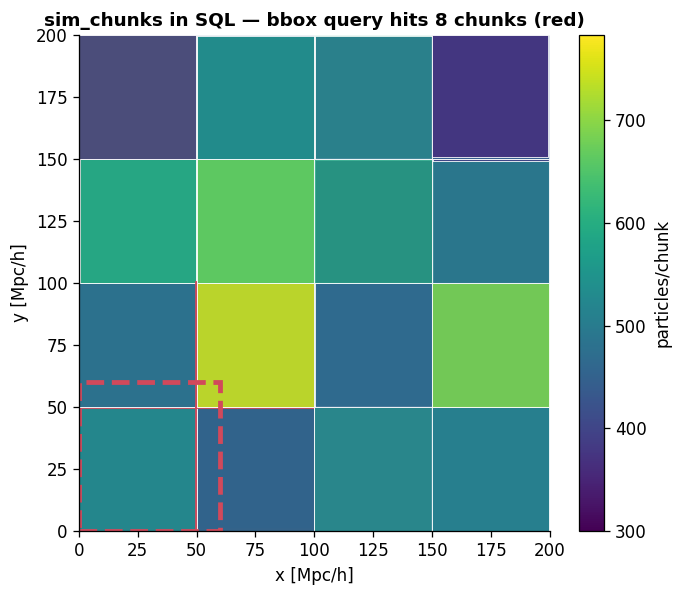

     product  chunks  rows_indexed
      fields       1           NaN
  fields_amr       1           NaN
   gr_fields       1           NaN
       halos       8         895.0
ic_posterior       1           NaN
   lightcone      48         895.0
 phase_space      64       32768.0
   snapshots      64       32768.0


In [5]:
from oneuniverse.simulation.linear import generate_linear_sim
from oneuniverse.simulation.oufsim import write_oufsim_store
from oneuniverse.simulation.oufsim.sql import export_sim_sql
lin=generate_linear_sim(TMP/'lin',COSMO,box_size=200.,n_grid=32,redshifts=(0.,),seed=2)
store=write_oufsim_store(lin,TMP/'st',sim_name='demo',particle_chunk_nside=4)
sdb=export_sim_sql(store,TMP/'sim.sqlite'); scon=sqlite3.connect(sdb)
ch=pd.read_sql_query("SELECT chunk_id,xlo,xhi,ylo,yhi,n_rows FROM sim_chunks "
                     "WHERE product='snapshots' AND z=0.0", scon)
qx=(0,60); qy=(0,60)
hit=pd.read_sql_query("SELECT chunk_id FROM sim_chunks WHERE product='snapshots' AND z=0.0 "
    "AND NOT (xhi<? OR xlo>? OR yhi<? OR ylo>? OR zhi<0 OR zlo>60)", scon,
    params=[qx[0],qx[1],qy[0],qy[1]])['chunk_id'].tolist()
fig,ax=plt.subplots(figsize=(6.6,5.6))
norm=plt.Normalize(ch['n_rows'].min(),ch['n_rows'].max())
for _,r in ch.iterrows():
    sel = r['chunk_id'] in hit
    ax.add_patch(Rectangle((r['xlo'],r['ylo']),r['xhi']-r['xlo'],r['yhi']-r['ylo'],
        fc=plt.cm.viridis(norm(r['n_rows'])), ec=(C1 if sel else 'white'), lw=(2.2 if sel else .6), alpha=.85))
ax.add_patch(Rectangle((qx[0],qy[0]),qx[1]-qx[0],qy[1]-qy[0],fill=False,ec=C1,lw=3,ls='--'))
ax.set_xlim(0,200); ax.set_ylim(0,200); ax.set_xlabel('x [Mpc/h]'); ax.set_ylabel('y [Mpc/h]')
ax.set_title(f'sim_chunks in SQL — bbox query hits {len(hit)} chunks (red)')
plt.colorbar(plt.cm.ScalarMappable(norm=norm,cmap='viridis'),ax=ax,label='particles/chunk')
plt.show()
print(pd.read_sql_query('SELECT product, COUNT(*) chunks, SUM(n_rows) rows_indexed '
                        'FROM sim_chunks GROUP BY product', scon).to_string(index=False))

## Zero-copy mode
For huge catalogs, don't copy at all: generated DuckDB views read the existing parquet in place — the SQL face of *wrap-in-place*.

In [6]:
print(attach_sql_ddl([view]))
con.close(); scon.close()

-- oneuniverse attach-mode DDL (ouf); run in DuckDB
CREATE OR REPLACE VIEW eboss AS SELECT * FROM read_parquet('/tmp/tmp7x5hbpp2/eboss/oneuniverse/data/**/*.parquet', hive_partitioning=1);


**What this showed.** Both databases speak SQL: real-survey questions as `GROUP BY`/`WHERE IN`, the cross-match as a JOIN, the simulation chunk map as a relational bbox query, and a zero-copy DuckDB path when materialising is the wrong answer.